# snRNA cross-cohort QC metrics comparison

Compare SIMPlex biological specimens (breast, prostate, mouse, technical) vs external FFPE references.

Cohorts are **pooled and relabelled** for publication (e.g. all breast patients → `FFPE BC SIMPlex`, both technical tubes → `Non-Visium SN`). Outputs: all-cohort figure (`qc_cohort_comparison`), breast-focused figure (`qc_breast_cohort_comparison`), and summary table (`qc_cohort_summary.csv`) under `figs/technical/metrics_comparison/`.

Uses **raw QC metadata** from each loaded object as-is — no post-merge `nFeature_RNA` filter.

**Out of scope:** spatial / SpaceRanger / Visium data.

**Prerequisite:** run `qc_doubletRemoval.ipynb` technical section first so
`data/single_nuclei/r_objects/technical_experiments/*_noDoublets.rds` exist.

**Reference patterns:**
- Cross-cohort QC: `scripts/rmd/breast_cancer/analysis_majorLevel.rmd` (~lines 2636–2808)
- Gene scatter: `scripts/rmd/mouse_brain/qc_metrics.Rmd`

**Environment:** `simplex` conda env (kernel **R (simplex renv)**).


## Set up


In [1]:
source(here::here("config.R"))
set.seed(1)


## Load libraries


In [2]:
suppressMessages(require(Seurat))
suppressMessages(require(Matrix))
suppressMessages(require(dplyr))
suppressMessages(require(tidyr))
suppressMessages(require(stringr))
suppressMessages(require(magrittr))
suppressMessages(require(patchwork))
suppressMessages(require(ggplot2))
suppressMessages(require(ggpubr))


Warning message in library(package, lib.loc = lib.loc, character.only = TRUE, logical.return = TRUE, :
“there is no package called ‘ggpubr’”


## Config

Toggle cohorts on/off. No additional QC filtering is applied after merge.


In [3]:
INCLUDE_BREAST    <- TRUE
INCLUDE_PROSTATE  <- TRUE
INCLUDE_MOUSE     <- TRUE
INCLUDE_TECHNICAL <- TRUE
INCLUDE_SNPATHO   <- TRUE
INCLUDE_10X_BC    <- TRUE
INCLUDE_10X_MOUSE <- TRUE

TECH_SAMPLES <- c("SIMPlex_Rev001_Tube1", "SIMPlex_Rev001_Tube2")
FIG_DIR <- file.path(FIGS_ROOT, "technical", "metrics_comparison")
dir.create(FIG_DIR, recursive = TRUE, showWarnings = FALSE)


## Tier 1 — CellRanger / CellBender CSV metrics (technical tubes)

Read per-tube summary CSVs and inspect side-by-side.


In [4]:
# CellRanger: CELLRANGER/technical_experiments/outs_<sample>/outs/per_sample_outs/<sample>/metrics_summary.csv
# CellBender: CELLBENDER/technical_experiments/outs_<sample>/<sample>_cellbender_metrics.csv

tier1 <- lapply(TECH_SAMPLES, function(sample) {
  cr_path <- file.path(
    CELLRANGER, "technical_experiments", paste0("outs_", sample),
    "outs", "per_sample_outs", sample, "metrics_summary.csv"
  )
  cb_path <- file.path(
    CELLBENDER, "technical_experiments", paste0("outs_", sample),
    paste0(sample, "_cellbender_metrics.csv")
  )
  list(
    sample = sample,
    cellranger = if (file.exists(cr_path)) read.csv(cr_path) else NULL,
    cellbender = if (file.exists(cb_path)) read.csv(cb_path) else NULL
  )
})
tier1


Category,Library.Type,Grouped.By,Group.Name,Metric.Name,Metric.Value
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
Cells,Gene Expression,,,Cells,"17,567"
Cells,Gene Expression,,,Confidently mapped reads in cells,79.1%
Cells,Gene Expression,,,Mean reads per cell,"2,999"
Cells,Gene Expression,,,Median UMI counts per cell,261
Cells,Gene Expression,,,Median genes per cell,200
Cells,Gene Expression,,,Total genes detected,"16,125"
Library,Gene Expression,,,Estimated UMIs from genomic DNA,0.4%
Library,Gene Expression,,,Estimated UMIs from genomic DNA per unspliced probe,1
Library,Gene Expression,Fastq ID,Tube1,Number of reads,"68,085,715"


## Tier 2 — Load cohorts, merge, publication QC figures

Objects are pooled into **seven cohorts** before plotting:

| Plot label | Source | Pooling |
|------------|--------|---------|
| FFPE BC SIMPlex | `SIMPlex_breast_allSamples.rds` | all breast patients |
| FFPE Prostate SIMPlex | `pt10_HD` + `pt20_HD` RDS | both prostate patients |
| Mouse Brain SIMPlex | `mouse_brain/snRNA.rds` | — |
| Non-Visium SN | technical `*_noDoublets.rds` | both Rev001 tubes |
| 10X FFPE BC | 10x public BC h5 | — |
| 10X FFPE Mouse Forebrain | 10x public mouse h5 | — |
| snPatho FFPE | snPATHO integrated RDS (FFPE only) | patients 4066, 4399, 4411 |


In [31]:
qc_list <- list()

# specimen_id: dataset-specific sample/library identity (used for violin n)
# breast -> unique sample; prostate -> one per RDS; mouse/10x -> one each;
# snPatho -> sample_id; technical -> one per tube

# --- breast ---
if (INCLUDE_BREAST) {
  qc <- readRDS(file.path(SN_RDS, "breast_cancer/cross_patient/SIMPlex_breast_allSamples.rds"))
  qc$sample <- paste0("BC_", qc$sample)
  qc$specimen_id <- as.character(qc$sample)
  qc_list$breast <- qc
}

# --- prostate ---
if (INCLUDE_PROSTATE) {
  prost1 <- readRDS(file.path(SN_RDS, "prostate_cancer/pt10_HD_seuratAnnotation.rds"))
  prost1$sample <- "FFPE Prostate SIMPlex"
  prost1$specimen_id <- as.character(prost1$orig.ident)
  prost2 <- readRDS(file.path(SN_RDS, "prostate_cancer/pt20_HD_seuratAnnotation.rds"))
  prost2$sample <- "FFPE Prostate SIMPlex"
  prost2$specimen_id <- as.character(prost2$orig.ident)
  qc_list$prostate <- list(prost1, prost2)
}

# --- mouse ---
if (INCLUDE_MOUSE) {
  mouse <- readRDS(file.path(SN_RDS, "mouse_brain/snRNA.rds"))
  mouse$sample <- "Mouse Brain SIMPlex"
  mouse$specimen_id <- "Mouse Brain SIMPlex"
  qc_list$mouse <- mouse
}

# --- technical (requires *_noDoublets.rds from qc_doubletRemoval.ipynb) ---
if (INCLUDE_TECHNICAL) {
  tech <- lapply(TECH_SAMPLES, function(s) {
    obj <- readRDS(file.path(SN_RDS, "technical_experiments", paste0(s, "_noDoublets.rds")))
    obj$sample <- "Non-Visium SN"
    obj$specimen_id <- s
    obj
  })
  qc_list$technical <- tech
}

# --- external refs ---
if (INCLUDE_SNPATHO) {
  snpatho_files <- sort(list.files(
    file.path(EXT_REFS, "snPATHO"),
    pattern = "_integrated_seuarat_object\\.rds$",
    full.names = TRUE
  ))
  stopifnot(length(snpatho_files) > 0L)
  snpatho_objs <- lapply(snpatho_files, function(f) {
    obj <- readRDS(f)
    stopifnot("sample_id" %in% colnames(obj[[]]))
    obj <- subset(obj, subset = processing_method == "FFPE_snPATHO")
    obj$sample <- "snPatho FFPE"
    obj$specimen_id <- as.character(obj$sample_id)
    obj
  })
  snPatho <- Reduce(function(x, y) merge(x, y), snpatho_objs)
  qc_list$snpatho <- snPatho
}

if (INCLUDE_10X_BC) {
  tenx <- Read10X_h5(file.path(
    EXT_REFS,
    "10x_BC_FFPE/320k_scFFPE_16-plex_GEM-X_FLEX_BreastCancer1_BC7-8_count_sample_filtered_feature_bc_matrix.h5"
  ))
  tenx <- CreateSeuratObject(counts = tenx)
  tenx$sample <- "10X FFPE BC"
  tenx$specimen_id <- as.character(tenx$sample)
  qc_list$tenx_bc <- tenx
}

if (INCLUDE_10X_MOUSE) {
  mfb <- Read10X_h5(file.path(
    EXT_REFS,
    "mouse_forebrain_10x/10k_mouse_forebrain_scFFPE_singleplex_count_sample_filtered_feature_bc_matrix.h5"
  ))
  mfb <- CreateSeuratObject(counts = mfb)
  mfb$sample <- "10X FFPE Mouse Forebrain"
  mfb$specimen_id <- as.character(mfb$sample)
  qc_list$tenx_mouse <- mfb
}


Warning message:
“Some cell names are duplicated across objects provided. Renaming to enforce unique cell names.”


In [32]:
# Specimen audit at load (before merge)
if (INCLUDE_BREAST) cat("Breast specimens:", length(unique(qc_list$breast$specimen_id)), "\n")
if (INCLUDE_PROSTATE) cat("Prostate specimens:", length(unlist(lapply(qc_list$prostate, function(x) unique(x$specimen_id)))), "\n")
if (INCLUDE_MOUSE) cat("Mouse specimens:", length(unique(qc_list$mouse$specimen_id)), "\n")
if (INCLUDE_TECHNICAL) cat("Technical specimens:", length(unlist(lapply(qc_list$technical, function(x) unique(x$specimen_id)))), "\n")
if (INCLUDE_SNPATHO) cat("snPatho specimens:", length(unique(qc_list$snpatho$specimen_id)), "\n")
if (INCLUDE_10X_BC) cat("10x BC specimens:", length(unique(qc_list$tenx_bc$specimen_id)), "\n")
if (INCLUDE_10X_MOUSE) cat("10x mouse specimens:", length(unique(qc_list$tenx_mouse$specimen_id)), "\n")


Breast specimens: 10 
Prostate specimens: 2 
Mouse specimens: 1 
Technical specimens: 2 
snPatho specimens: 3 
10x BC specimens: 1 
10x mouse specimens: 1 


In [33]:
# Merge all loaded cohorts
flat <- unlist(qc_list, recursive = FALSE)
merged <- merge(x = flat[[1]], y = flat[-1])

# --- cohort labels  ---
COHORT_LEVELS <- c(
  "FFPE BC SIMPlex",
  "10X FFPE BC",
  "snPatho FFPE",
  "FFPE Prostate SIMPlex",
  "Mouse Brain SIMPlex",
  "10X FFPE Mouse Forebrain",
  "Non-Visium SN"
)

COHORT_COLORS <- c(
  "FFPE BC SIMPlex"           = "#5B4B8A",
  "FFPE Prostate SIMPlex"     = "#7B68EE",
  "Mouse Brain SIMPlex"       = "#9370DB",
  "Non-Visium SN"     = "#E8923A",
  "10X FFPE BC"               = "#2E7D6E",
  "10X FFPE Mouse Forebrain"  = "#3DAA96",
  "snPatho FFPE"              = "#3A7CA5"
)

COHORT_GROUP <- c(
  "FFPE BC SIMPlex"           = "SIMPlex biological",
  "FFPE Prostate SIMPlex"     = "SIMPlex biological",
  "Mouse Brain SIMPlex"       = "SIMPlex biological",
  "Non-Visium SN"     = "Non-Visium technical control",
  "10X FFPE BC"               = "External FFPE reference",
  "10X FFPE Mouse Forebrain"  = "External FFPE reference",
  "snPatho FFPE"              = "External FFPE reference"
)

TISSUE_CONTEXT <- c(
  "FFPE BC SIMPlex"           = "Breast cancer",
  "10X FFPE BC"               = "Breast cancer",
  "snPatho FFPE"              = "Breast cancer",
  "FFPE Prostate SIMPlex"     = "Prostate cancer",
  "Mouse Brain SIMPlex"       = "Mouse brain",
  "10X FFPE Mouse Forebrain"  = "Mouse brain",
  "Non-Visium SN"     = "Technical Control"
)

assign_cohort <- function(sample) {
  sample <- as.character(sample)
  dplyr::case_when(
    # Breast SIMPlex (prefixed or raw patient IDs)
    grepl("^BC_", sample) ~ "FFPE BC SIMPlex",
    grepl("^patient[0-9]", sample) ~ "FFPE BC SIMPlex",
    # Prostate SIMPlex
    sample %in% c(
      "FFPE Prostate SIMPlex", "Prostate_HD_pat10", "Prostate_HD_pat20",
      "pt10_ap5_5", "pt20_p2_2"
    ) ~ "FFPE Prostate SIMPlex",
    # Mouse SIMPlex
    sample %in% c(
      "Mouse Brain SIMPlex", "Mouse_Brain", "MB_2_simplex", "MB_2"
    ) ~ "Mouse Brain SIMPlex",
    # Non-Visium technical control
    sample %in% c("Non-Visium SN", "Non-Visium SN Control") ~ "Non-Visium SN",
    grepl("^Tech_", sample) ~ "Non-Visium SN",
    grepl("^SIMPlex_Rev001_Tube", sample) ~ "Non-Visium SN",
    # snPATHO FFPE
    sample %in% c("snPatho FFPE") ~ "snPatho FFPE",
    grepl("^snPatho_", sample) ~ "snPatho FFPE",
    # 10x public FFPE references
    sample %in% c("10X FFPE BC", "10X_FFPE_BC") ~ "10X FFPE BC",
    sample %in% c("10X FFPE Mouse Forebrain", "10X_FFPE_MouseForebrain") ~ "10X FFPE Mouse Forebrain",
    TRUE ~ NA_character_
  )
}

merged$percent.mt <- PercentageFeatureSet(merged, pattern = "(?i)^mt-")
merged$percent.ribo <- PercentageFeatureSet(merged, pattern = "(?i)^rp[ls]")

qc_meta <- merged[[]]
qc_meta$cohort <- assign_cohort(qc_meta$sample)
qc_meta$log10_nCount <- log10(qc_meta$nCount_RNA + 1)

# Diagnose any unmapped labels before plotting
unmapped <- qc_meta[is.na(qc_meta$cohort), , drop = FALSE]
if (nrow(unmapped) > 0L) {
  bad <- sort(unique(unmapped$sample))
  warning(
    nrow(unmapped), " nuclei could not be mapped to a cohort. ",
    "Unmapped sample labels: ", paste(bad, collapse = ", ")
  )
  print(data.frame(sample = bad, n = as.integer(table(unmapped$sample)[bad])))
  qc_meta <- qc_meta[!is.na(qc_meta$cohort), , drop = FALSE]
}

qc_meta$cohort <- factor(qc_meta$cohort, levels = COHORT_LEVELS)
qc_meta$cohort_group <- factor(
  unname(COHORT_GROUP[as.character(qc_meta$cohort)]),
  levels = c("SIMPlex biological", "Non-Visium technical control", "External FFPE reference")
)
qc_meta$tissue_context <- factor(
  unname(TISSUE_CONTEXT[as.character(qc_meta$cohort)]),
  levels = c("Breast cancer", "Prostate cancer", "Mouse brain", "Technical Control")
)

cat("Sample label -> cohort mapping:\n")
print(
  qc_meta %>%
    dplyr::distinct(sample, cohort) %>%
    dplyr::arrange(cohort, sample)
)

cat("\nNuclei per cohort:\n")
print(table(qc_meta$cohort))

if (!"specimen_id" %in% colnames(qc_meta)) {
  stop("specimen_id missing from merged metadata — set per dataset in load cell")
}

cat("\nSpecimens per cohort (dataset-specific specimen_id):\n")
specimen_audit <- qc_meta %>%
  dplyr::group_by(cohort) %>%
  dplyr::summarise(
    n_specimens = dplyr::n_distinct(specimen_id),
    specimens = paste(sort(unique(specimen_id)), collapse = ", "),
    .groups = "drop"
  )
print(specimen_audit)


Warning message:
“Some cell names are duplicated across objects provided. Renaming to enforce unique cell names.”


Sample label -> cohort mapping:
                                                   sample
TATGCATTCCGGATAGACTTTAGG-1_1_1           BC_patient1_55um
AAGCTTAAGACAAGCTAACGGGAA-1_2_1           BC_patient2_55um
AGCCTCTAGTGATGGTATGTTGAC-1_1_3_1         BC_patient4_55um
ACCTGGAAGCATCTATAACGGGAA-1_1_4_1           BC_patient4_HD
GATTGCTGTATCCGCAAACGGGAA-1_1_5_1         BC_patient5_55um
AACCAACAGTATGGGTAGTAGGCT-1_6_1             BC_patient5_HD
TTCCTCTAGACTCCTAACTTTAGG-1_1_7_1         BC_patient6_55um
AGTAAGCTCGCTTCGGATGTTGAC-1_8_1           BC_patient7_55um
TCGTTGCAGTTACACTAGTAGGCT-1_9_1           BC_patient8_55um
AGCGCTAAGCCCTGATAACGGGAA-1_10_1          BC_patient9_55um
AAACAAGCAAACCGGTAAGTAGAG-1_8                  10X FFPE BC
AGGTTGAGTGTTTGTA-1_1_1_7                     snPatho FFPE
CAAGGCCAGTTGCAGGATGTTGAC-1_2        FFPE Prostate SIMPlex
TTCGCGCCACCATCAT-1_4                  Mouse Brain SIMPlex
AAACAAGCAAACCCAA-1_9             10X FFPE Mouse Forebrain
TGTAAGTCAGCTTTCG-1_5                    

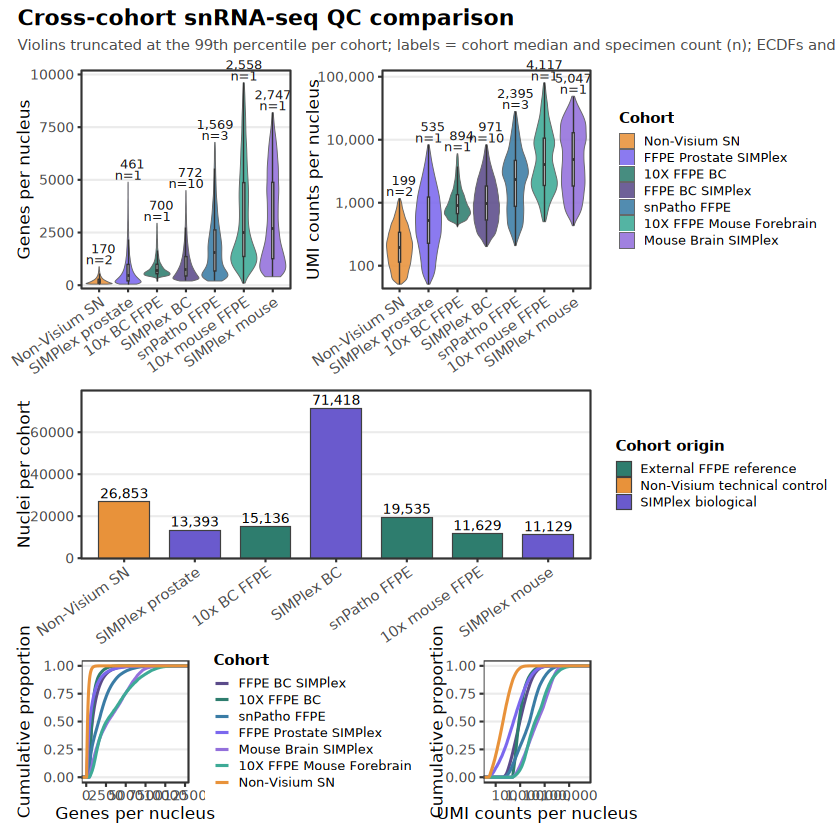

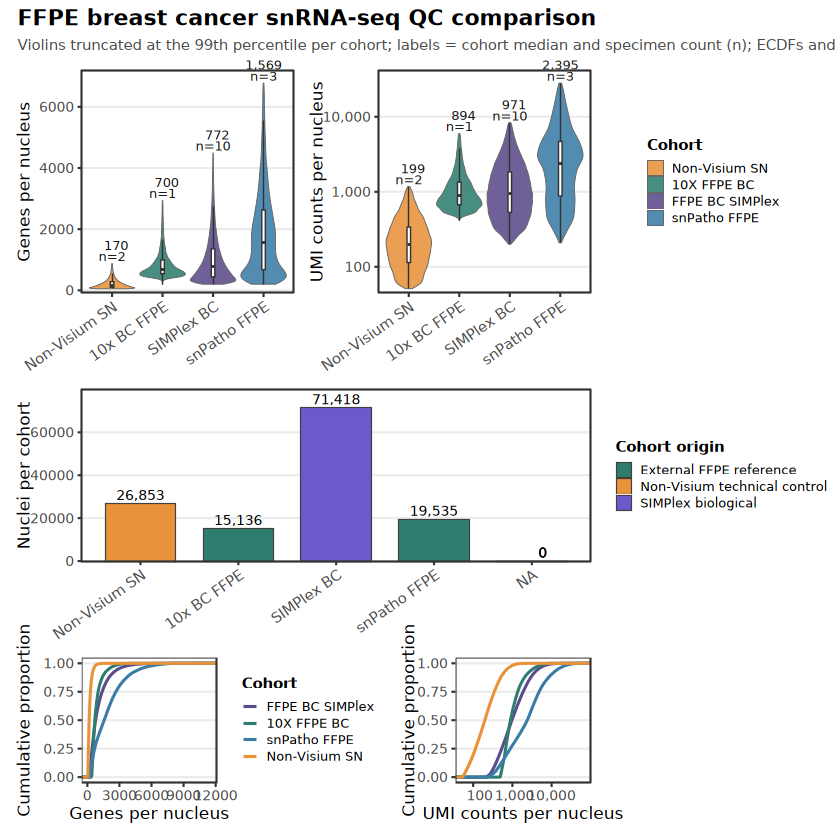

In [41]:
# --- plotting helpers ---
theme_pub <- function() {
  theme_bw(base_size = 10) +
    theme(
      panel.grid.minor = element_blank(),
      panel.grid.major.x = element_blank(),
      strip.background = element_rect(fill = "grey95", color = NA),
      strip.text = element_text(face = "bold"),
      legend.position = "bottom",
      plot.title = element_text(face = "bold", size = 10),
      axis.title = element_text(size = 10)
    )
}

legend_theme_side <- function() {
  theme(
    legend.position = "right",
    legend.box = "vertical",
    legend.background = element_rect(fill = "white", color = NA),
    legend.key.size = grid::unit(0.35, "cm"),
    legend.text = element_text(size = 7.5),
    legend.title = element_text(size = 8.5, face = "bold"),
    plot.margin = margin(5, 6, 5, 5, "pt")
  )
}

COHORT_SHORT <- stats::setNames(
  c(
    "SIMPlex BC", "10x BC FFPE", "snPatho FFPE",
    "SIMPlex prostate", "SIMPlex mouse", "10x mouse FFPE",
    "Non-Visium SN"
  ),
  COHORT_LEVELS
)

cohort_x_labels <- function(cohort_chr) {
  unname(COHORT_SHORT[cohort_chr])
}

qc_summary <- qc_meta %>%
  dplyr::group_by(cohort, cohort_group, tissue_context) %>%
  dplyr::summarise(
    n_specimens = dplyr::n_distinct(specimen_id),
    specimens = paste(sort(unique(specimen_id)), collapse = "; "),
    n_nuclei = dplyr::n(),
    median_genes = median(nFeature_RNA, na.rm = TRUE),
    median_UMIs = median(nCount_RNA, na.rm = TRUE),
    median_pct_mt = median(percent.mt, na.rm = TRUE),
    median_pct_ribo = median(percent.ribo, na.rm = TRUE),
    .groups = "drop"
  )

write.csv(qc_summary, file.path(FIG_DIR, "qc_cohort_summary.csv"), row.names = FALSE)

# Shared x-axis order for violin + counts panels (by ascending median genes)
COHORT_LEVELS_PLOT <- qc_summary %>%
  dplyr::arrange(median_genes, match(cohort, COHORT_LEVELS)) %>%
  dplyr::pull(cohort) %>%
  as.character()

VIOLIN_PCTL_CAP <- 0.99

truncate_violin_by_cohort <- function(df, metric, p = VIOLIN_PCTL_CAP) {
  df %>%
    dplyr::group_by(cohort) %>%
    dplyr::filter(
      .data[[metric]] <= stats::quantile(.data[[metric]], p, na.rm = TRUE)
    ) %>%
    dplyr::ungroup()
}

violin_stat_labels <- function(df, metric, y_ref) {
  dplyr::summarise(
    dplyr::group_by(df, cohort),
    median = median(.data[[metric]], na.rm = TRUE),
    .groups = "drop"
  ) %>%
    dplyr::left_join(
      dplyr::summarise(
        dplyr::group_by(y_ref, cohort),
        y_top = max(.data[[metric]], na.rm = TRUE),
        .groups = "drop"
      ),
      by = "cohort"
    ) %>%
    dplyr::left_join(
      qc_summary %>% dplyr::select(cohort, n_specimens),
      by = "cohort"
    )
}

plot_qc_violin <- function(
    df, metric, ylab, cohort_levels,
    log_y = FALSE, show_labels = TRUE, show_legend = FALSE,
    p_cap = VIOLIN_PCTL_CAP) {
  df <- df %>%
    dplyr::filter(cohort %in% cohort_levels) %>%
    dplyr::mutate(cohort = factor(cohort, levels = cohort_levels))
  df_plot <- truncate_violin_by_cohort(df, metric, p_cap)
  stats <- violin_stat_labels(df, metric, y_ref = df_plot)
  p <- ggplot2::ggplot(df_plot, ggplot2::aes(x = cohort, y = .data[[metric]], fill = cohort)) +
    ggplot2::geom_violin(
      scale = "width", trim = TRUE, linewidth = 0.2,
      color = "grey40", alpha = 0.88
    ) +
    ggplot2::geom_boxplot(
      width = 0.07, outlier.shape = NA,
      fill = "white", color = "grey20", linewidth = 0.3
    ) +
    ggplot2::scale_fill_manual(
      values = COHORT_COLORS, name = "Cohort",
      guide = if (show_legend) "legend" else "none"
    ) +
    ggplot2::scale_x_discrete(labels = cohort_x_labels) +
    ggplot2::labs(x = NULL, y = ylab) +
    ggplot2::coord_cartesian(clip = "off") +
    theme_pub() +
    theme(axis.text.x = element_text(angle = 35, hjust = 1, size = 8.5))

  if (log_y) {
    p <- p + ggplot2::scale_y_log10(
      labels = function(x) format(x, scientific = FALSE, big.mark = ","),
      expand = ggplot2::expansion(mult = c(0.02, 0.06))
    )
  } else {
    p <- p + ggplot2::scale_y_continuous(expand = ggplot2::expansion(mult = c(0.02, 0.06)))
  }

  if (show_labels) {
    p <- p + ggplot2::geom_text(
      data = stats,
      ggplot2::aes(
        x = cohort,
        y = y_top,
        label = sprintf(
          "%s\nn=%d",
          format(round(median), big.mark = ","),
          n_specimens
        )
      ),
      inherit.aes = FALSE, size = 2.6, color = "grey10",
      lineheight = 0.75, vjust = -0.12
    )
  }
  if (show_legend) {
    p <- p + legend_theme_side()
  }
  p
}

qc_figure_subtitle <- paste0(
  "Violins truncated at the ", VIOLIN_PCTL_CAP * 100,
  "th percentile per cohort; labels = cohort median and specimen count (n); ",
  "ECDFs and bar chart use all nuclei"
)

build_qc_figure <- function(
    df,
    cohort_levels,
    title,
    file_stem,
    width = 13,
    height = 12) {
  df <- df %>% dplyr::filter(cohort %in% cohort_levels)

  counts_df <- as.data.frame(table(df$cohort))
  colnames(counts_df) <- c("cohort", "N")
  counts_df$cohort_group <- unname(COHORT_GROUP[as.character(counts_df$cohort)])
  counts_df$cohort <- factor(counts_df$cohort, levels = cohort_levels)

  p_counts <- ggplot2::ggplot(counts_df, ggplot2::aes(x = cohort, y = N, fill = cohort_group)) +
    ggplot2::geom_col(color = "grey25", linewidth = 0.25, width = 0.72) +
    ggplot2::geom_text(
      ggplot2::aes(label = format(N, big.mark = ",")),
      vjust = -0.35, size = 2.8
    ) +
    ggplot2::scale_fill_manual(
      values = c(
        "SIMPlex biological" = "#6A5ACD",
        "Non-Visium technical control" = "#E8923A",
        "External FFPE reference" = "#2E7D6E"
      ),
      name = "Cohort origin"
    ) +
    ggplot2::scale_x_discrete(labels = cohort_x_labels) +
    ggplot2::scale_y_continuous(expand = ggplot2::expansion(mult = c(0, 0.12))) +
    ggplot2::labs(x = NULL, y = "Nuclei per cohort") +
    ggplot2::coord_cartesian(clip = "off") +
    theme_pub() +
    theme(axis.text.x = element_text(angle = 35, hjust = 1, size = 8.5))

  p_ecdf_genes <- ggplot2::ggplot(df, ggplot2::aes(x = nFeature_RNA, color = cohort)) +
    ggplot2::stat_ecdf(linewidth = 0.65) +
    ggplot2::scale_color_manual(values = COHORT_COLORS, name = "Cohort") +
    ggplot2::labs(x = "Genes per nucleus", y = "Cumulative proportion") +
    theme_pub()

  p_ecdf_umis <- ggplot2::ggplot(df, ggplot2::aes(x = nCount_RNA, color = cohort)) +
    ggplot2::stat_ecdf(linewidth = 0.65) +
    ggplot2::scale_color_manual(values = COHORT_COLORS, guide = "none") +
    ggplot2::scale_x_log10(labels = function(x) format(x, scientific = FALSE, big.mark = ",")) +
    ggplot2::labs(x = "UMI counts per nucleus", y = "Cumulative proportion") +
    theme_pub()

  p_out <- (
    plot_qc_violin(
      df, "nFeature_RNA", "Genes per nucleus",
      cohort_levels = cohort_levels, show_legend = FALSE
    ) |
    plot_qc_violin(
      df, "nCount_RNA", "UMI counts per nucleus",
      cohort_levels = cohort_levels, log_y = TRUE, show_legend = TRUE
    )
  ) /
    (p_counts + legend_theme_side()) /
    (p_ecdf_genes + legend_theme_side() | p_ecdf_umis) +
    patchwork::plot_annotation(
      title = title,
      subtitle = qc_figure_subtitle,
      theme = theme(
        plot.title = element_text(face = "bold", size = 13),
        plot.subtitle = element_text(size = 8.5, colour = "grey30")
      )
    ) +
    patchwork::plot_layout(heights = c(1.1, 0.85, 0.62), widths = c(1, 1))

  ggplot2::ggsave(file.path(FIG_DIR, paste0(file_stem, ".pdf")), p_out, width = width, height = height)
  ggplot2::ggsave(
    file.path(FIG_DIR, paste0(file_stem, ".png")),
    p_out, width = width, height = height, dpi = 300
  )
  p_out
}

BREAST_QC_COHORTS <- c(
  "Non-Visium SN",
  "10X FFPE BC",
  "FFPE BC SIMPlex",
  "snPatho FFPE"
)

BREAST_COHORT_LEVELS_PLOT <- qc_summary %>%
  dplyr::filter(cohort %in% BREAST_QC_COHORTS) %>%
  dplyr::arrange(median_genes, match(cohort, BREAST_QC_COHORTS)) %>%
  dplyr::pull(cohort) %>%
  as.character()

p_qc <- build_qc_figure(
  df = qc_meta,
  cohort_levels = COHORT_LEVELS_PLOT,
  title = "Cross-cohort snRNA-seq QC comparison",
  file_stem = "qc_cohort_comparison"
)

p_qc_breast <- build_qc_figure(
  df = qc_meta,
  cohort_levels = BREAST_COHORT_LEVELS_PLOT,
  title = "FFPE breast cancer snRNA-seq QC comparison",
  file_stem = "qc_breast_cohort_comparison",
  width = 11,
  height = 12
)

print(p_qc)
print(p_qc_breast)


## Session info


In [39]:
sessionInfo()


R version 4.3.3 (2024-02-29)
Platform: x86_64-conda-linux-gnu (64-bit)
Running under: Red Hat Enterprise Linux 9.7 (Plow)

Matrix products: default
BLAS/LAPACK: /srv/home/m.abreumachado/apps/miniconda3/envs/simplex/lib/libopenblasp-r0.3.26.so;  LAPACK version 3.12.0

locale:
 [1] LC_CTYPE=en_US.UTF-8       LC_NUMERIC=C              
 [3] LC_TIME=en_US.UTF-8        LC_COLLATE=en_US.UTF-8    
 [5] LC_MONETARY=en_US.UTF-8    LC_MESSAGES=en_US.UTF-8   
 [7] LC_PAPER=en_US.UTF-8       LC_NAME=C                 
 [9] LC_ADDRESS=C               LC_TELEPHONE=C            
[11] LC_MEASUREMENT=en_US.UTF-8 LC_IDENTIFICATION=C       

time zone: Europe/Stockholm
tzcode source: system (glibc)

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
 [1] ggplot2_3.5.2      patchwork_1.2.0    magrittr_2.0.4     stringr_1.5.1     
 [5] tidyr_1.3.1        dplyr_1.1.4        Matrix_1.6-5       Seurat_5.2.1      
 [9] SeuratObject_5.0.2 